## Exercise 15 — Boston Crime Rate Analysis

Using the Boston dataset, we predict per capita crime rate (`crim`) from all other variables.

- **(a)** Fit a simple linear regression for each predictor separately. Identify which have a significant association with crime.
- **(b)** Fit a multiple regression using all predictors. Compare which are significant when considered jointly.
- **(c)** Compare univariate vs. multivariate coefficients in a scatterplot.
- **(d)** Test for non-linear associations by fitting cubic polynomials $Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon$ for each predictor.

In [1]:

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import statsmodels.api as sm

from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
                        summarize ,
                        poly)

In [2]:
Boston = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [3]:
y = Boston['crim']
univariate = {}

for pred_i in Boston.drop(columns='crim').columns:
    X_i = MS([pred_i]).fit_transform(Boston)
    results_i = sm.OLS(y, X_i).fit()
    univariate[pred_i] = {
        'coef': results_i.params.iloc[-1],
        'std_err': results_i.bse.iloc[-1],
        't': results_i.tvalues.iloc[-1],
        'p_value': results_i.pvalues.iloc[-1],
    }

uni_df = pd.DataFrame(univariate).T
uni_df

,coef,std_err,t,p_value
zn,-0.073935,0.016095,-4.593776,5.506472e-06
indus,0.509776,0.051024,9.990848,1.450349e-21
chas,-1.892777,1.506115,-1.256727,2.094345e-01
nox,31.248531,2.999190,10.418989,3.751739e-23
rm,-2.684051,0.532041,-5.044819,6.346703e-07
age,0.107786,0.012736,8.462825,2.854869e-16
dis,-1.550902,0.168330,-9.213458,8.519949e-19
rad,0.617911,0.034332,17.998199,2.693844e-56
tax,0.029742,0.001847,16.099388,2.357127e-47
ptratio,1.151983,0.169374,6.801430,2.942922e-11


In [4]:
uni_df['coef']

zn         -0.073935
indus       0.509776
chas       -1.892777
nox        31.248531
rm         -2.684051
age         0.107786
dis        -1.550902
rad         0.617911
tax         0.029742
ptratio     1.151983
lstat       0.548805
medv       -0.363160
Name: coef, dtype: float64

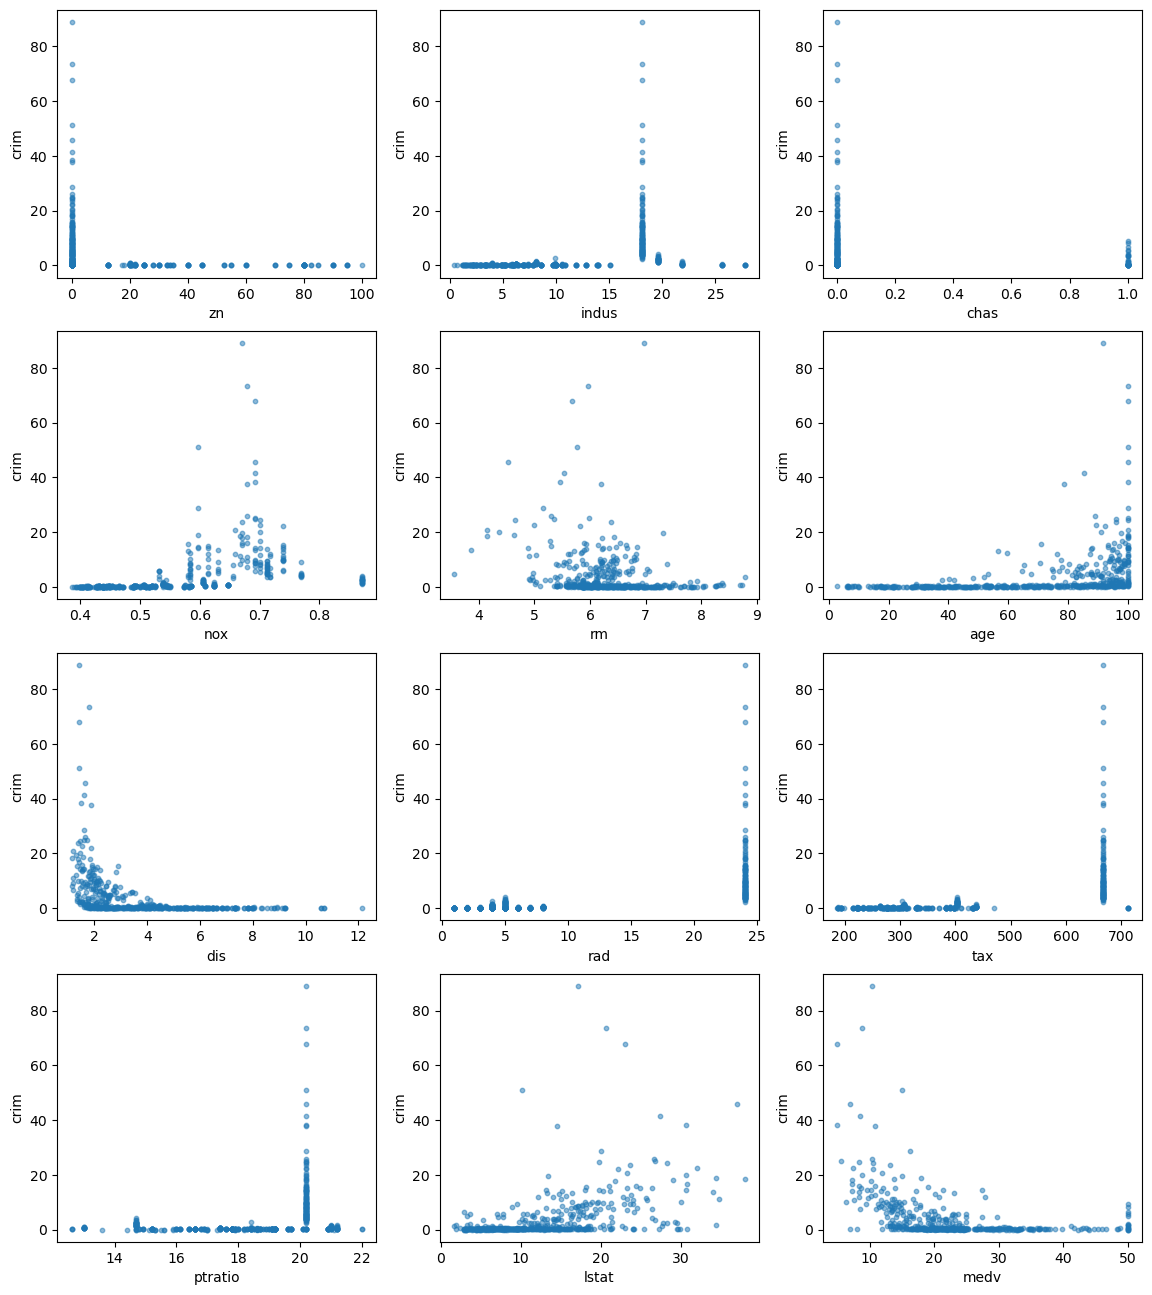

In [5]:
predictors = Boston.drop(columns='crim').columns
fig, axes = subplots(4, 3, figsize=(14, 16))
axes = axes.flatten()

for i, pred in enumerate(predictors):
    axes[i].scatter(Boston[pred], y, s=10, alpha=0.5)
    axes[i].set_xlabel(pred)
    axes[i].set_ylabel('crim')

# hide any unused subplot
for j in range(len(predictors), len(axes)):
    axes[j].set_visible(False)



From the univariate p-values, all predictors except chas show a statistically significant linear association with crime rate. However, the scatter plots reveal that "statistically significant" does not mean "well described by a line."

### Using all the predictors at once 


In [6]:
predictors = Boston.drop(columns='crim').columns
X_tot = MS(predictors).fit_transform(Boston)
model_tot = sm.OLS(y,X_tot)
results_tot = model_tot.fit()
summarize(results_tot)



,coef,std err,t,P>|t|
intercept,13.7784,7.082,1.946,0.052
zn,0.0457,0.019,2.433,0.015
indus,-0.0584,0.084,-0.698,0.486
chas,-0.8254,1.183,-0.697,0.486
nox,-9.9576,5.290,-1.882,0.060
rm,0.6289,0.607,1.036,0.301
age,-0.0008,0.018,-0.047,0.962
dis,-1.0122,0.282,-3.584,0.000
rad,0.6125,0.088,6.997,0.000
tax,-0.0038,0.005,-0.730,0.466


Predictors such as: indus,chas,rm,age,tax and ptratio have a p-value largely superior to 0.05, other predictors, nox and lstat, show a more mitigated effect with a p-value close to 0.05. In any case these is a clear sign of overlap of the information carried by the predictors. Many predictors that were relevant taken singularly are non-significant in the joint model, this is the trademark of collinearity.

(-2.0, 1.0)

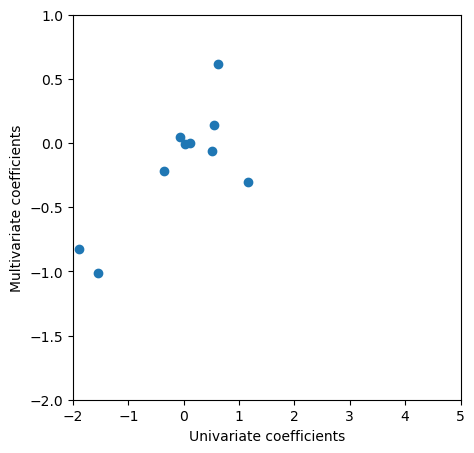

In [9]:
ax = subplots(figsize=(5, 5))[1]
predictors = Boston.drop(columns='crim').columns
ax.scatter(uni_df.loc[predictors, 'coef'], results_tot.params[predictors])
ax.set_xlabel('Univariate coefficients')
ax.set_ylabel('Multivariate coefficients')
ax.set_xlim(-2,5)
ax.set_ylim(-2,1)

The results from the univariate regressions and the multivariate regression are different. If they agreed, all points would lie on the X=Y diagonal. Instead they are scattered everywhere some change sign some shrink and other grow. It is clear the difference between:

* Marginal association: relationship between X_j and Y ignoring all the other predictors.
* Conditional association: relations between X_j and Y keeping fixed the values of all the other predictors. 

In [17]:
y = Boston['crim']
nonlinear = {}

for pred_i in Boston.drop(columns=['crim', 'chas']).columns:  # skip chas (binary)
    X_i = MS([poly(pred_i, degree=3)]).fit_transform(Boston)
    results_i = sm.OLS(y, X_i).fit()
    nonlinear[pred_i] = {
        'p_linear': results_i.pvalues.iloc[1],
        'p_quadratic': results_i.pvalues.iloc[2],
        'p_cubic': results_i.pvalues.iloc[3],
    }

nl_df = pd.DataFrame(nonlinear).T
nl_df

,p_linear,p_quadratic,p_cubic
zn,4.697806e-06,4.420507e-03,2.295386e-01
indus,8.854243e-24,1.086057e-03,1.196405e-12
nox,2.457491e-26,7.736755e-05,6.961110e-16
rm,5.128048e-07,1.508545e-03,5.085751e-01
age,4.878803e-17,2.291156e-06,6.679915e-03
dis,1.253249e-21,7.869767e-14,1.088832e-08
rad,1.053211e-56,9.120558e-03,4.823138e-01
tax,6.976314e-49,3.665348e-06,2.438507e-01
ptratio,1.565484e-11,2.405468e-03,6.300514e-03
lstat,1.678072e-27,3.780418e-02,1.298906e-01
